# Módulo 30 - K-Means
**Atividade:**

Nesta tarefa, vamos explorar o algoritmo de clustering K-means aplicado a um contexto diferente do usual. Em vez de segmentar perfis de viajantes ou clientes de e-commerce, vamos usar dados biológicos para segmentar diferentes espécies de pinguins com base em características físicas. Esta abordagem destaca a versatilidade do K-means para diversas áreas além de vendas e marketing.

A base de dados utilizada é a penguins do pacote seaborn, que contém informações sobre três espécies de pinguins: Adelie, Chinstrap e Gentoo. As variáveis disponíveis incluem medições físicas dos pinguins coletadas na Antártica.

species: Espécie do pinguim (Adelie, Chinstrap, Gentoo)

island: Ilha onde o pinguim foi observado (Biscoe, Dream, Torgersen)

bill_length_mm: Comprimento do bico em milímetros

bill_depth_mm: Profundidade do bico em milímetros

flipper_length_mm: Comprimento da barbatana em milímetros

body_mass_g: Massa corporal em gramas

sex: Sexo do pinguim (Male, Female)

year: Ano em que a observação foi feita

In [1]:
import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [2]:
penguins = sns.load_dataset('penguins')

In [3]:
penguins

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


# 1 - Nesse exercício vocês devem verificar se temos variáveis missing, faltantes e excluir esses valores do dataset, também devem excluir as colunas com valores categóricos, que não utilizazam para o Kmeans.

In [4]:
# seu código aqui

In [5]:
#Verificar NaN
penguins.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [6]:
#Remover NaN, e verificar
penguins.dropna(inplace=True)
penguins.isna().sum()

species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
dtype: int64

In [7]:
#Remover colunas com valores categóricos e verificar colunas resultantes
penguins.drop(columns=['species','island','sex'], inplace=True)
print(penguins.columns.tolist())

['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']


# 2 - Visualize a análise descritiva dos seus dados utilizando a função vista em aula pairplot. É possível já identificar possíveis agrupamentos? Se sim, quantos?

In [8]:
# seu código aqui

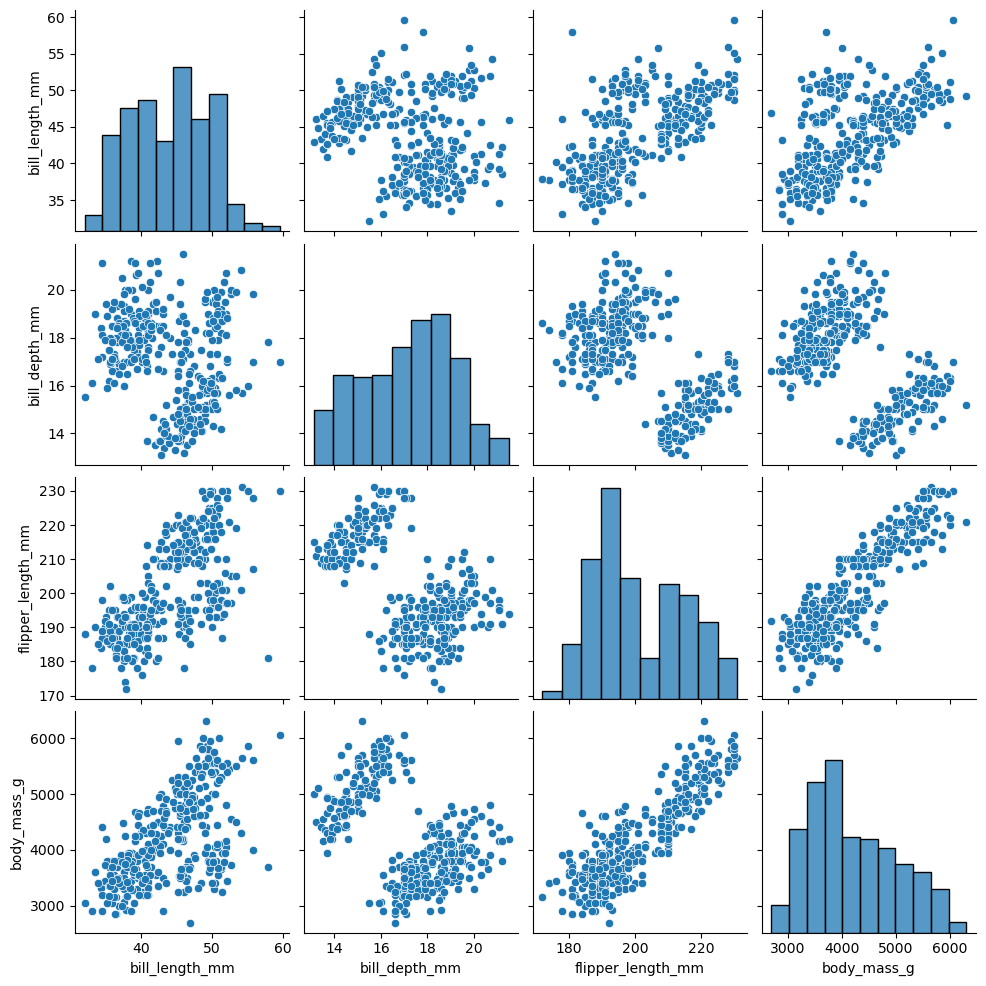

In [9]:
sns.pairplot(penguins)

Sim, é possivel vizualizar possivéis agrupamentos, 3 grupos distintos observados, como por exemplo observado no grafico *bill_lenght* x *flipper_lenght*

# 3 - Realize a padronização dos dados e visualize os dados.

In [ ]:
# seu código aqui

In [11]:
#Padronizar os dados
scaler = StandardScaler()

dados_padronizados = scaler.fit_transform(penguins)

penguins_padronizados = pd.DataFrame(dados_padronizados, columns=penguins.columns)

print("Primeiras linhas do dataset padronizado:")
display(penguins_padronizados.head())

Primeiras linhas do dataset padronizado:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
0,-0.896042,0.780732,-1.426752,-0.568475
1,-0.822788,0.119584,-1.069474,-0.506286
2,-0.676280,0.424729,-0.426373,-1.190361
3,-1.335566,1.085877,-0.569284,-0.941606
4,-0.859415,1.747026,-0.783651,-0.692852


# 4 - Aplique o algoritmo do k means escolhendo o numero de clusters como igual a 3, que é que a quantidade de espécies que temos na base.

In [ ]:
# seu código aqui

In [12]:
kmeans_penguins_pad = KMeans (n_clusters=3, random_state=42)
kmeans_penguins_pad.fit(penguins_padronizados)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [16]:
centroides_pad = kmeans_penguins_pad.cluster_centers_

centroides_pad

array([[-1.04680889,  0.48662566, -0.88169491, -0.7627539 ],
       [ 0.65475809, -1.10270671,  1.16246305,  1.10121078],
       [ 0.67202511,  0.80526339, -0.28934658, -0.38410387]])

In [19]:
labels = kmeans_penguins_pad.labels_
labels

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 2,
       0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0,
       0, 2, 0, 2, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0,
       0, 2, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 2, 0, 2,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2,
       0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [18]:
centroides_ori = scaler.inverse_transform(centroides_pad)
centroides_ori

array([[  38.27674419,   18.12170543,  188.62790698, 3593.79844961],
       [  47.56806723,   14.99663866,  217.23529412, 5092.43697479],
       [  47.66235294,   18.74823529,  196.91764706, 3898.23529412]])

# 5 - Construa pelo menos 2 matriz de dispersão como realizada em aula indicando os pontos e centroides.

**Comece usando x='bill_length_mm' e y='bill_depth_mm' para analisar o primeiro gráfico e em seguida escolha outras variaveis para o segundo.**

In [ ]:
# seu código aqui

In [ ]:
#'flipper_length_mm': penguins['flipper_length_mm'],
#    'body_mass_g': penguins['body_mass_g'],

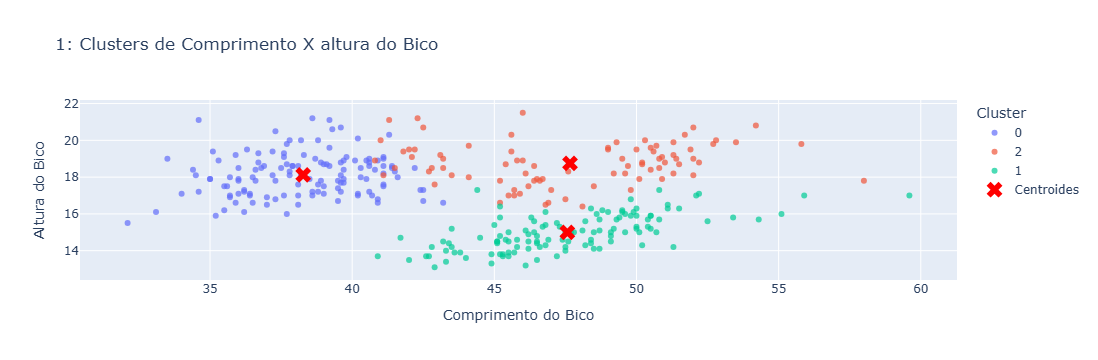

In [32]:
# Criando um df com os dados originais e  rótulos de cluster
df_clusters = pd.DataFrame({
    'bill_length_mm': penguins['bill_length_mm'],
    'bill_depth_mm': penguins['bill_depth_mm'],
    'cluster': labels.astype(str)
})

# Plotar os pontos de dados coloridos
fig = px.scatter(df_clusters, x='bill_length_mm', y='bill_depth_mm', color='cluster',
                 color_continuous_scale='viridis', opacity=0.7,
                 title='1: Clusters de Comprimento X altura do Bico')

# Adicionar os centroides ao gráfico
fig.add_scatter(x=centroides_ori[:, 0], y=centroides_ori[:, 1],
                mode='markers', marker=dict(color='red', symbol='x', size=14),
                name='Centroides')


fig.update_layout(xaxis_title='Comprimento do Bico', yaxis_title='Altura do Bico',
                  legend_title='Cluster')
fig.show()

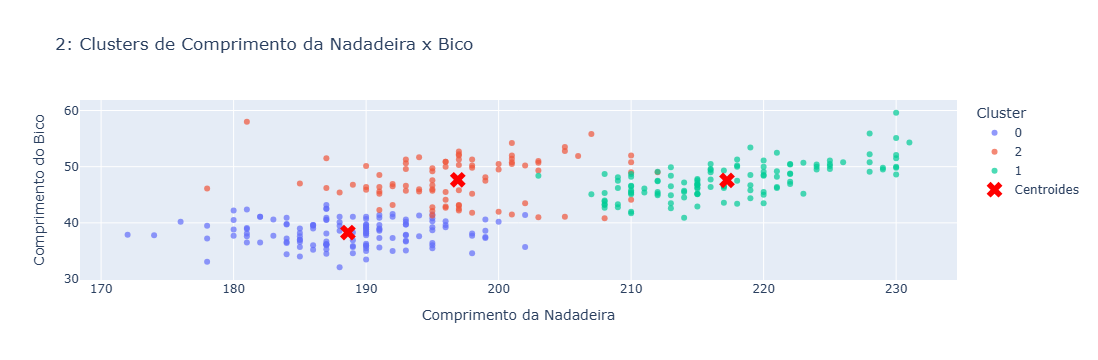

In [36]:
# Criando um df com os dados originais e  rótulos de cluster
df_clusters = pd.DataFrame({
    'flipper_length_mm': penguins['flipper_length_mm'],
    'bill_length_mm': penguins['bill_length_mm'],
    'cluster': labels.astype(str)
})

# Plotar os pontos de dados coloridos
fig = px.scatter(df_clusters, x='flipper_length_mm', y='bill_length_mm', color='cluster',
                 color_continuous_scale='viridis', opacity=0.7,
                 title='2: Clusters de Comprimento da Nadadeira x Bico')

# Adicionar os centroides ao gráfico
fig.add_scatter(x=centroides_ori[:, 2], y=centroides_ori[:, 0],
                mode='markers', marker=dict(color='red', symbol='x', size=14),
                name='Centroides')


fig.update_layout(xaxis_title='Comprimento da Nadadeira', yaxis_title='Comprimento do Bico',
                  legend_title='Cluster')
fig.show()

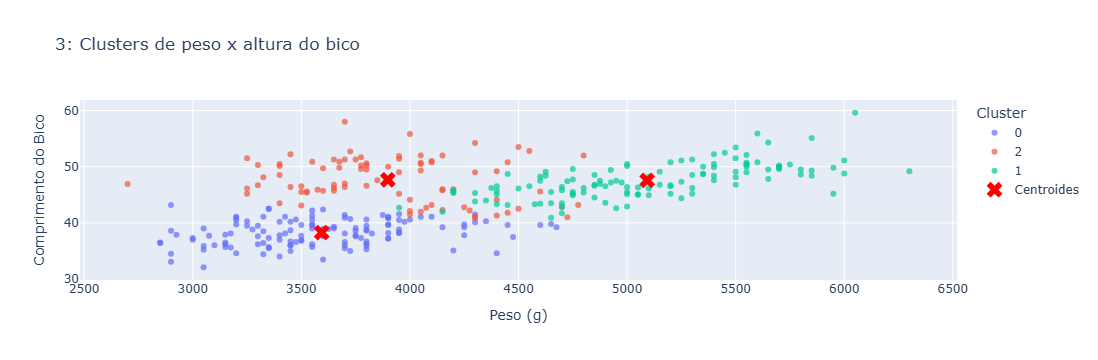

In [37]:
df_clusters = pd.DataFrame({
    'body_mass_g': penguins['body_mass_g'],
    'bill_length_mm': penguins['bill_length_mm'],
    'cluster': labels.astype(str)
})

# Plotar os pontos de dados coloridos
fig = px.scatter(df_clusters, x='body_mass_g', y='bill_length_mm', color='cluster',
                 color_continuous_scale='viridis', opacity=0.7,
                 title='3: Clusters de peso x altura do bico')

# Adicionar os centroides ao gráfico
fig.add_scatter(x=centroides_ori[:, 3], y=centroides_ori[:, 0],
                mode='markers', marker=dict(color='red', symbol='x', size=14),
                name='Centroides')


fig.update_layout(xaxis_title='Peso (g)', yaxis_title='Comprimento do Bico',
                  legend_title='Cluster')
fig.show()

# 6 - Pesquise mais 3 utilidades de aplicações de algoritmos de clusterização e cite abaixo:

- Segmentação de Clientes -  identificar grupos de consumidores com comportamentos semelhantes (ex.: hábitos de compra, ticket médio, preferências de produto);

- Organização de documentos e imagens - agrupar textos, artigos ou imagens semelhantes sem precisar de rótulos prévios (ex.: páginas por tema);

- Sistemas de recomendação - Agrupar usuários com comportamentos parecidos para sugerir produtos, músicas ou filmes (ex.: genero música, duração de musica ou file)